### Introduction
Apprentissage supervisé

L’apprentissage supervisé consiste à utiliser un jeu **de données étiqueté**, c’est-à-dire des données pour lesquelles on connaît à la fois les inputs (variables d’entrée) et les outputs (valeurs ou étiquettes de sortie).


Dans l’apprentissage supervisé, on distingue principalement deux grandes familles de problèmes :


*   La régression, où l’on prédit une valeur continue
*   La classification, où l’on prédit une catégorie parmi plusieurs possibles.



> Régression



La régression vise à estimer une valeur numérique en sortie.
Exemples :


*   prédire le prix d’un appartement,

*   estimer la durée de vie d’une pièce mécanique,
*   prévoir la durée de guérison d’un patient.



Parmi les modèles les plus simples et les plus utilisés pour la régression, on retrouve la régression linéaire, qui cherche à modéliser la relation entre les variables d’entrée et la variable cible sous forme de droite ou de plan.


> But de l’atelier



Dans cet atelier, nous allons voir comment appliquer la régression linéaire pas à pas en utilisant Google Colab. Nous allons :

charger et explorer un dataset,

visualiser les relations entre les variables,

entraîner un modèle de régression linéaire,

évaluer ses performances,

interpréter les coefficients obtenus.

À la fin de cet atelier, vous aurez une compréhension claire du fonctionnement de la régression linéaire et de la manière de l’implémenter dans un environnement Python interactif.

### Régression linéaire

In [1]:
!pip install pandas

In [3]:
import pandas as pd

###1. Charger le dataset

In [1]:
url = "https://raw.githubusercontent.com/AdiPersonalWorks/Random/master/student_scores%20-%20student_scores.csv"


In [4]:
df = pd.read_csv(url)

In [5]:
df

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


### 2. Explorer le dataset

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


 si je veux savoir le nombre des donnees monquants


In [46]:
df.isna().sum()

,0
Hours,0
Scores,0


voir les statistiques de dataset

In [47]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


le transpose de la matrice

In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours,25.0,5.012,2.525094,1.1,2.7,4.8,7.4,9.2
Scores,25.0,51.480,25.286887,17.0,30.0,47.0,75.0,95.0


### visualisation de dataset
   les nuages de points


In [49]:
import matplotlib.pyplot as plt

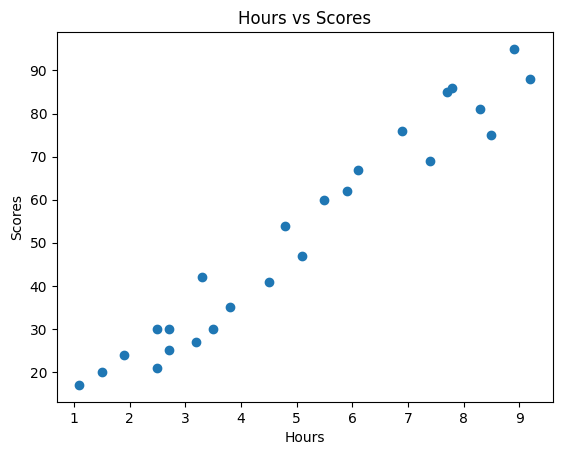

In [11]:
plt.scatter(df['Hours'],df['Scores'])
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("Hours vs Scores")
plt.show()

### construire le modèle IA.

Qu’est-ce que Scikit-Learn ?

Scikit-Learn (sklearn) est une bibliothèque Python spécialement conçue pour faire du machine learning.

Elle regroupe un ensemble d’outils prêts à l’emploi pour entraîner et tester des modèles d’apprentissage automatique.

En d’autres mots :

👉 C’est une boîte à outils pour construire facilement des modèles d’IA.

 on install sckit learn  

In [26]:
!pip install scikit-learn

In [14]:
X= df[['Hours']]
Y= df['Scores']

In [50]:
Y

,Scores
0,21
1,47
2,27
3,75
4,30
5,20
6,88
7,60
8,81
9,25


In [16]:
X

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2)

✦ test_size=0.2 → 20% des données pour tester, 80% pour entraîner

✦ random_state=42 → permet de refaire la même séparation à chaque exécution (optionnel)

✦ X_train → données d’entrée pour apprendre

✦ y_train → valeurs cibles pour apprendre

✦ X_test → nouvelles données inconnues

✦ y_test → vraies valeurs pour comparer avec les prédictions

 pour l'entraner on utilise la fonction fit  

In [32]:
from sklearn import linear_model

In [33]:
model = linear_model.LinearRegression()

In [34]:
model.fit(X_train, y_train)

LinearRegression()

In [37]:
valeur1 = model.predict([[5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [39]:
print(valeur1)

[50.92484393]


In [22]:
predicted= model.predict(X)

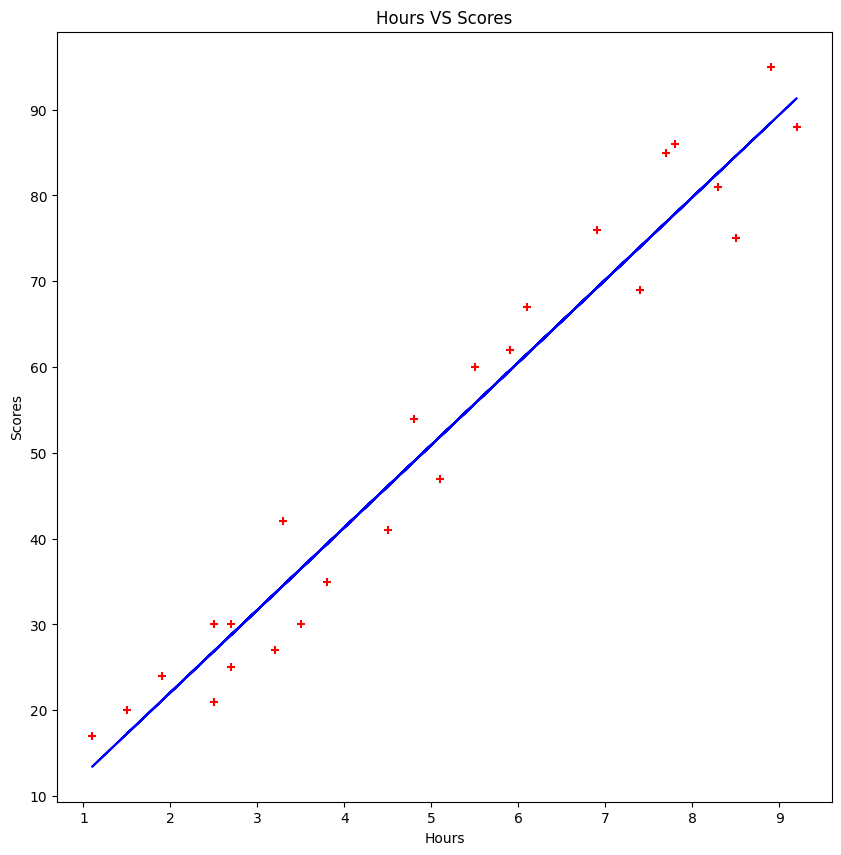

In [40]:
plt.figure(figsize=(10,10))
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("Hours VS Scores")
plt.scatter(df["Hours"],df["Scores"], color='red', marker='+')
plt.plot(X , predicted, color='blue')

### Évaluation du modèle (régression linéaire)
Après avoir entraîné un modèle (fit), il faut savoir :

➡️ Est-ce qu’il prédit bien ?

➡️ Est-ce qu’il généralise sur de nouvelles données ?

➡️ Est-ce qu’on peut lui faire confiance ?

Pour ça, on utilise l’évaluation du modèle.

### 1️⃣ Mean — Absolute Error (MAE)
C’est la moyenne des erreurs absolues :


*   Formule: $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

*   Plus elle est faible, meilleur est le modèle.


*   Elle est exprimée dans la même unité que la variable cible
### 2️⃣ MSE — Mean Squared Error



*   Formule: $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

*   C’est la moyenne des erreurs au carré.




*   Plus MSE est petit, mieux c’est.
*   Pénalise plus fortement les grosses erreurs.



### 3️⃣ RMSE — Root Mean Squared Error


*   Formule: $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
*   C’est la racine du MSE : $\sqrt{MSE}$.

*   Plus RMSE est petit, meilleur est le modèle

### 4️⃣ R² — Coefficient of Determination


*   Formule : $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$


*   Score entre 0 et 1 (parfois négatif).
*   Mesure la qualité globale du modèle.


*   R² = 1 → modèle parfait
*   R² = 0 → le modèle est aussi nul que prédire la moyenne


*   R² < 0 → le modèle est pire qu’un modèle trivial













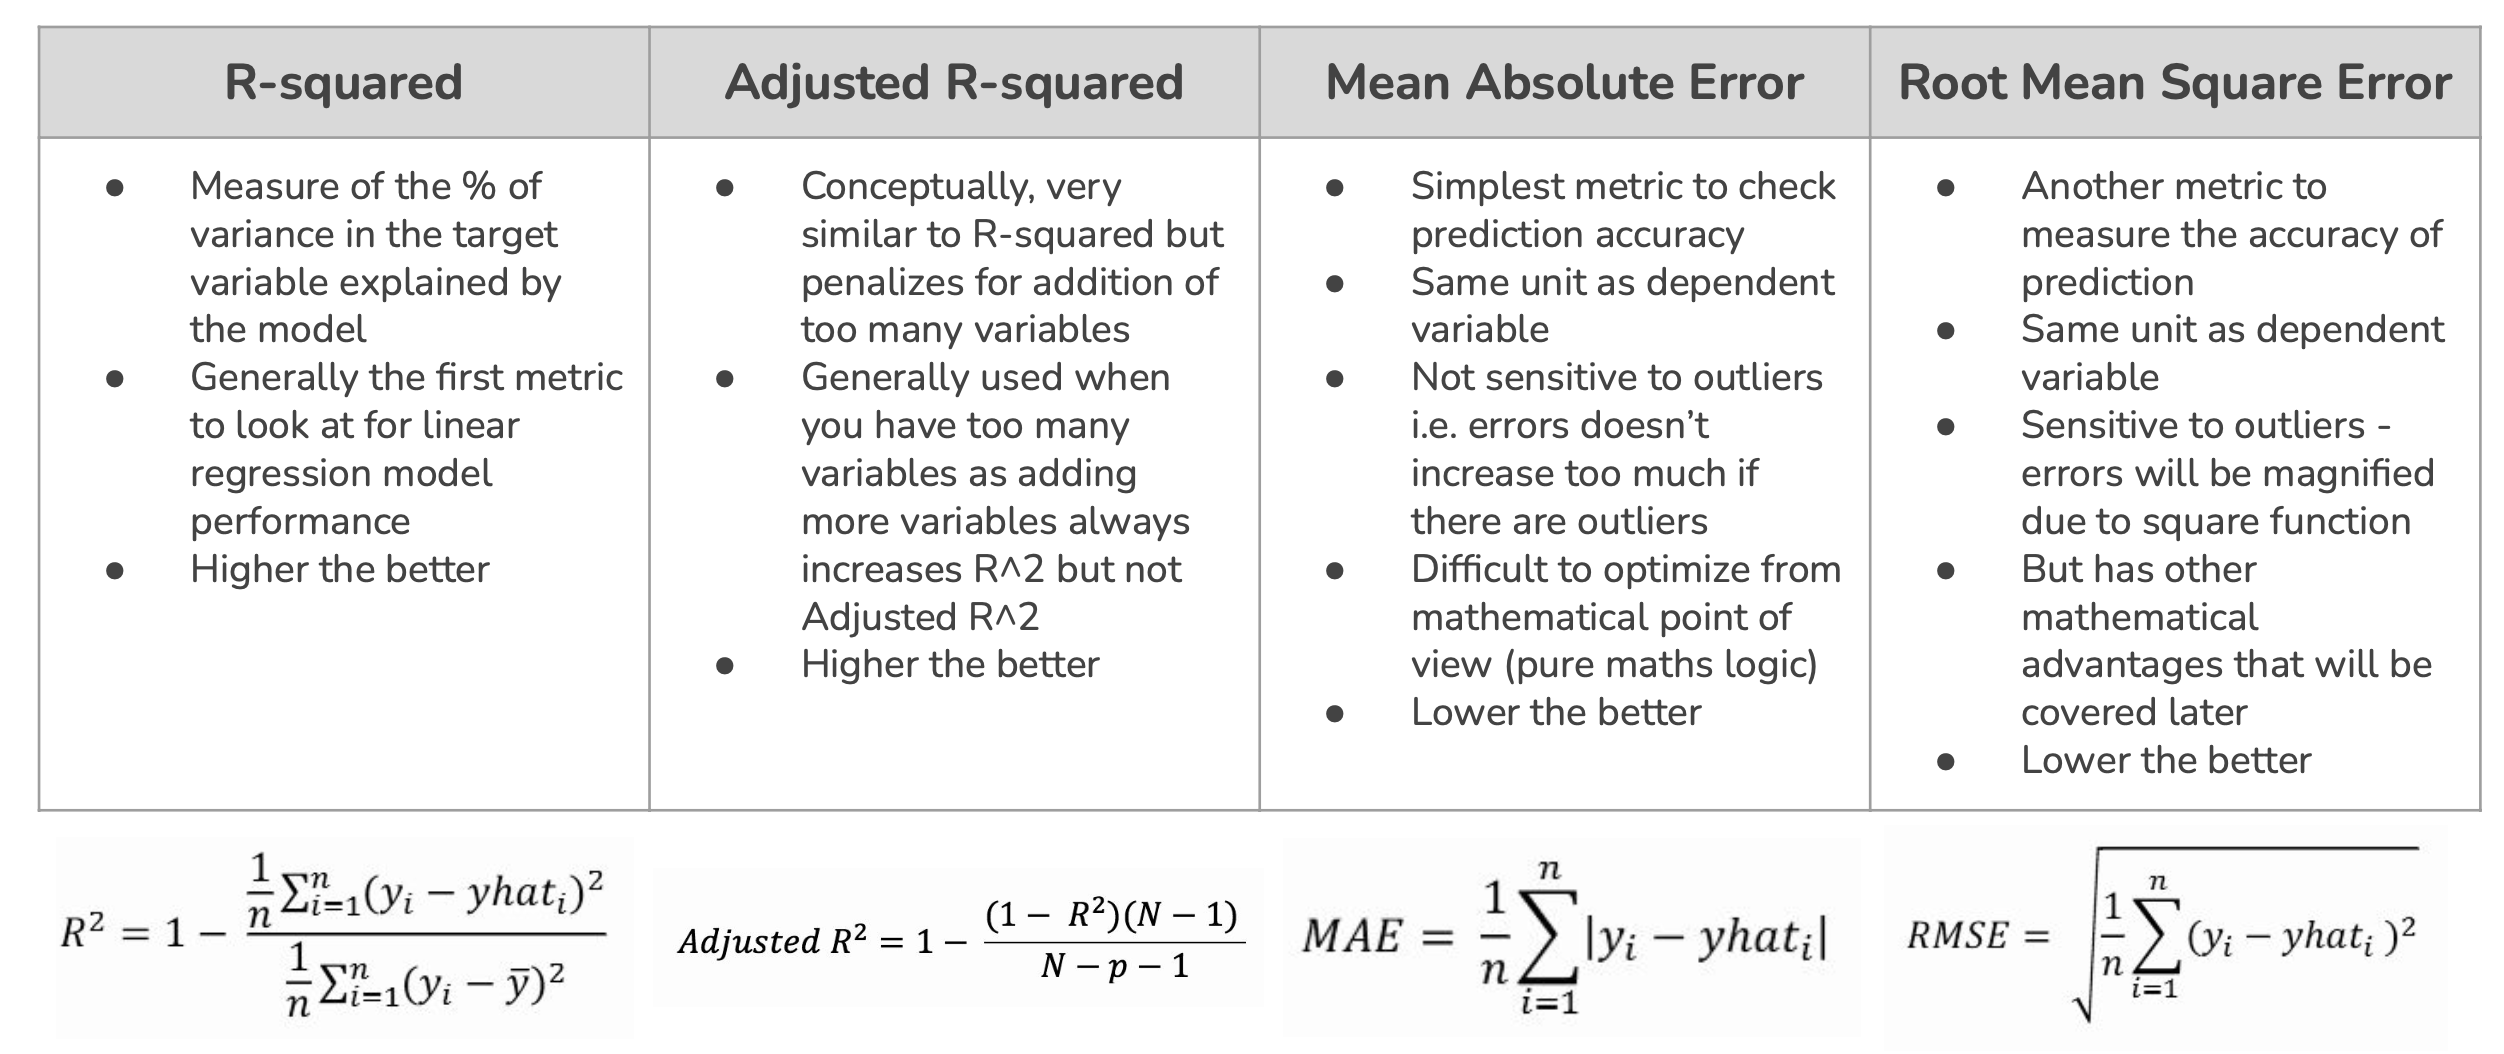

In [51]:
from sklearn import metrics

In [52]:
metrics.r2_score(Y,predicted)

0.952384192462452

In [53]:
metrics.mean_absolute_error(Y,predicted)

4.980469859886618

In [54]:
metrics.mean_squared_error(Y,predicted)

29.22894441060081

### Un autre exemple pour pratiquer le ML avec du data processing

In [55]:
df2 = pd.read_csv("prix_maisons2.csv")

In [56]:
df2

,area,rooms,age,city,price
0,100,3.0,4,Casablanca,1500000
1,120,4.0,10,Casablanca,1680000
2,260,NaN,20,Casablanca,3380000
3,190,5.0,1,Casablanca,3040000
4,260,5.0,4,Casablanca,3900000
5,60,2.0,3,Casablanca,1080000
6,100,3.0,4,Marrakech,1400000
7,120,4.0,10,Marrakech,1580000
8,260,5.0,20,Marrakech,3280000
9,190,5.0,1,Marrakech,2900000


In [57]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    18 non-null     int64  
 1   rooms   15 non-null     float64
 2   age     18 non-null     int64  
 3   city    18 non-null     object 
 4   price   18 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 852.0+ bytes


### pour savoir les valeurs maquantes

In [58]:
df2.isna().sum()

,0
area,0
rooms,3
age,0
city,0
price,0


In [29]:
df2.describe()

,area,rooms,age,price
count,18.00000,15.000000,18.00000,1.800000e+01
mean,165.00000,3.800000,7.00000,2.276667e+06
std,79.64997,1.207122,6.61549,9.947450e+05
min,60.00000,2.000000,1.00000,8.600000e+05
25%,100.00000,3.000000,3.00000,1.485000e+06
50%,155.00000,4.000000,4.00000,2.290000e+06
75%,260.00000,5.000000,10.00000,3.030000e+06
max,260.00000,5.000000,20.00000,3.900000e+06


In [84]:
median = df2['rooms'].median()

In [85]:
print(median)

4.0


on va remplacer les valeur manquantes par la median

In [86]:
df2['rooms'] = df2['rooms'].fillna(median)

In [87]:
df2

,area,rooms,age,city,price,city_label
0,100,3.0,4,Casablanca,1500000,0
1,120,4.0,10,Casablanca,1680000,0
2,260,4.0,20,Casablanca,3380000,0
3,190,5.0,1,Casablanca,3040000,0
4,260,5.0,4,Casablanca,3900000,0
5,60,2.0,3,Casablanca,1080000,0
6,100,3.0,4,Marrakech,1400000,1
7,120,4.0,10,Marrakech,1580000,1
8,260,5.0,20,Marrakech,3280000,1
9,190,5.0,1,Marrakech,2900000,1


In [88]:
df2['city'].value_counts()

,count
city,
Casablanca,6
Marrakech,6
Tanger,6


In [89]:
from sklearn import preprocessing

###  .fit() : apprend toutes les catégories uniques ('Paris', 'Tokyo', 'Londres')
.transform() : applique la transformation en nombres
.fit_transform() : fait les deux en une seule étape

In [90]:
encoder=preprocessing.LabelEncoder()

In [91]:
df2['city_label']=encoder.fit_transform(df2['city'])

In [92]:
df2

,area,rooms,age,city,price,city_label
0,100,3.0,4,Casablanca,1500000,0
1,120,4.0,10,Casablanca,1680000,0
2,260,4.0,20,Casablanca,3380000,0
3,190,5.0,1,Casablanca,3040000,0
4,260,5.0,4,Casablanca,3900000,0
5,60,2.0,3,Casablanca,1080000,0
6,100,3.0,4,Marrakech,1400000,1
7,120,4.0,10,Marrakech,1580000,1
8,260,5.0,20,Marrakech,3280000,1
9,190,5.0,1,Marrakech,2900000,1


In [113]:
 import seaborn as sns

<Axes: xlabel='area', ylabel='Count'>

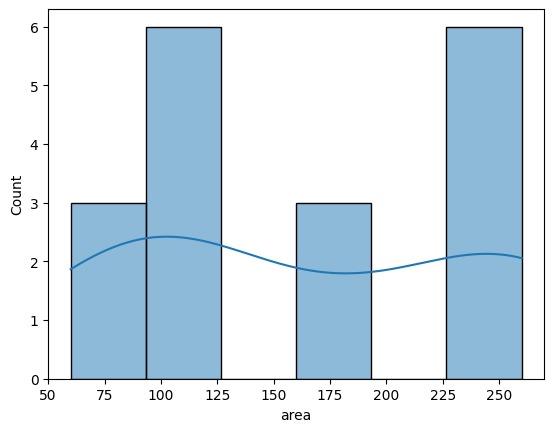

In [114]:
sns.histplot(df2['area'],kde=True)

In [66]:
y = df2['price']
x = df2.drop(columns=['price', 'city'])

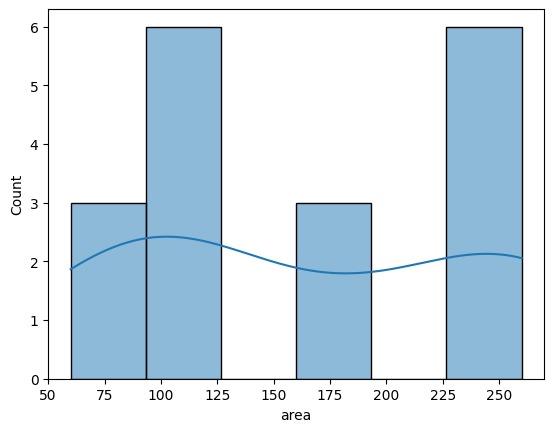

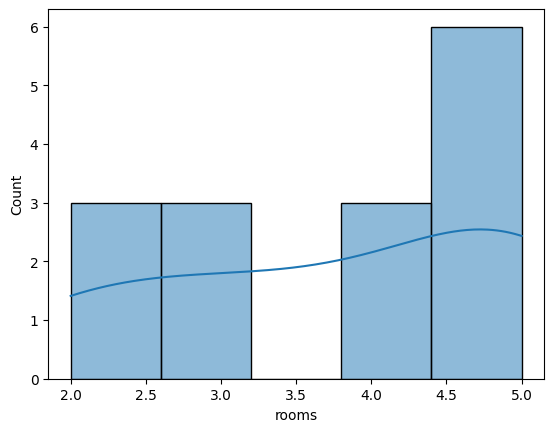

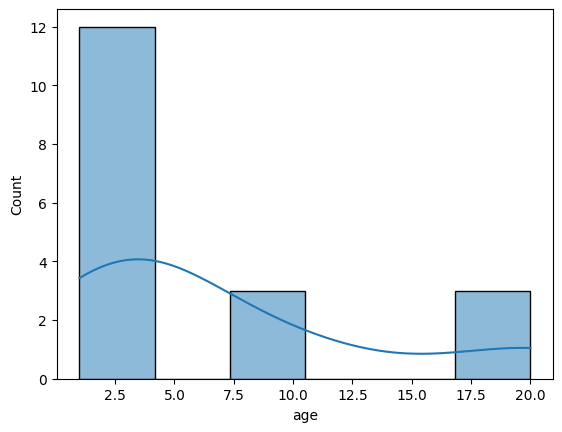

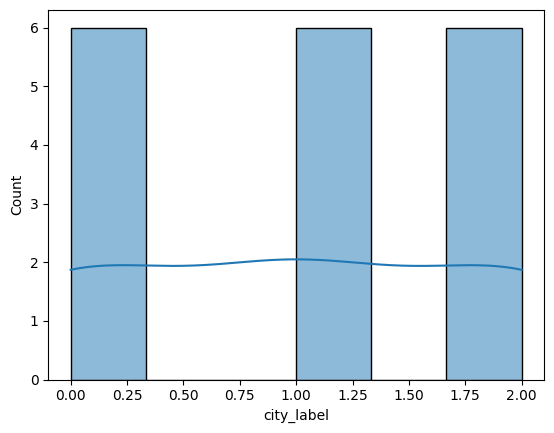

In [67]:
for col in x.columns:
    sns.histplot(x[col], kde=True )
    plt.show()

### on va voir la matrice de correlation
La matrice de corrélation est un tableau qui résume le degré de "parenté" ou de "liaison" entre chaque paire de variables dans votre jeu de données
Quand l'une augmente, qu'a tendance à faire l'autre ?

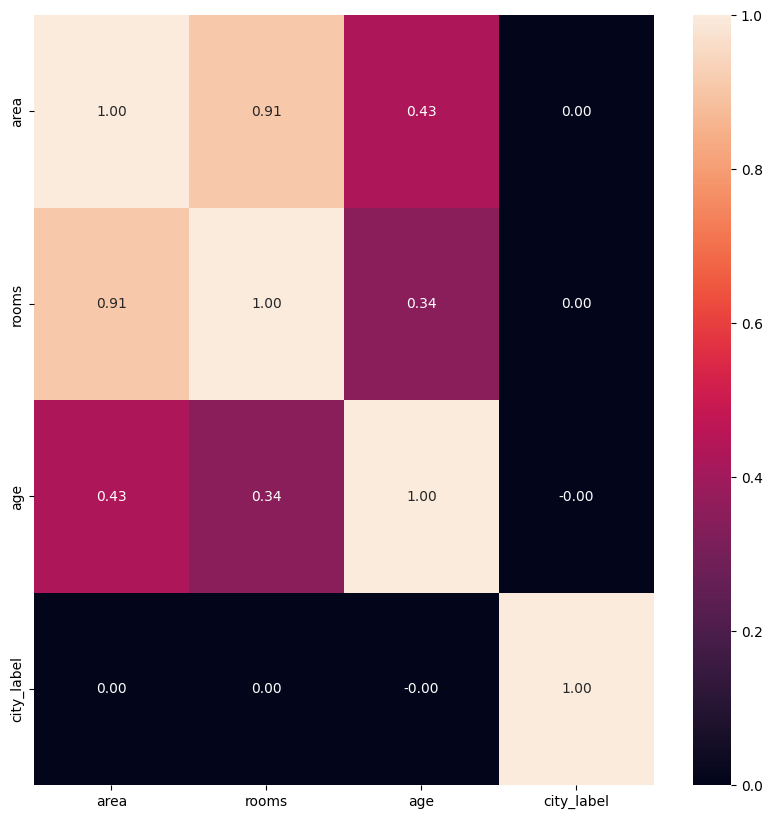

In [68]:
plt.figure(figsize=(10,10))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(x.corr(), annot=True , fmt= '.2f')
plt.show()


In [111]:
x.corr()

,area,rooms,age,city_label
area,1.000000,7.969505e-01,4.286814e-01,0.000000e+00
rooms,0.796950,1.000000e+00,3.076948e-01,-2.831409e-17
age,0.428681,3.076948e-01,1.000000e+00,-2.819969e-17
city_label,0.000000,-2.831409e-17,-2.819969e-17,1.000000e+00


In [105]:
from sklearn.model_selection import train_test_split

In [106]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1234 )

In [107]:
from sklearn import linear_model

In [108]:
modele2 = linear_model.LinearRegression()

In [109]:
modele2.fit(x_train, y_train)

LinearRegression()

In [117]:
valeur2=modele2.predict([[120, 3, 10, 1]])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [118]:
print(valeur2)

[1542607.44719321]


In [124]:
val3 =  modele2.predict([
    [100, 3, 4, 0],
    [120, 4, 10, 1],
    [200, 5, 2, 2]
])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [125]:
print(val3)

[1566680.2413901  1744812.47612141 2887273.81989976]



### Bias-Variance: Underfitting and Overfitting

C'est le concept le plus important pour comprendre pourquoi un modèle marche ou ne marche pas.

 C'est le cœur du métier de Data Scientist.

 Pour expliquer cela simplement, utilisons une analogie que tout le monde comprend :

  1. Les 3 Scénarios (Underfitting vs Overfitting)
  
  Imaginez trois étudiants qui doivent apprendre une courbe (les données) pour prédire le futur.
  
  **A. Underfitting (Sous-apprentissage)** - "Le Paresseux"L'étudiant : Il n'a presque pas révisé. Il pense que la réponse est toujours simple.
   Il trace une ligne droite alors que la courbe est complexe.Le Modèle : Il est trop simple pour capturer la logique des données.
   
   Symptôme : Il est mauvais à l'entraînement (Training) ET mauvais à l'examen (Test).
   
   Technicalité : Il a un Fort Biais (il a trop de préjugés).
   
  **B. Overfitting (Sur-apprentissage)** - "Le Perroquet"L'étudiant : Il a appris par cœur les réponses des exercices du livre, mais il n'a pas compris la logique.
  
  Si on change un seul chiffre à l'examen, il est perdu.Le Modèle : Il est trop complexe.
  
   Il relie tous les points, même le bruit (les erreurs) et les anomalies.
   
   Il colle trop aux données d'entraînement.Symptôme : Il a 20/20 à l'entraînement (génial !), mais 5/20 à l'examen (catastrophe).
   
   Technicalité : Il a une Forte Variance (il est instable).
   
   
**C. Good Fitting (Le juste milieu)** - "L'Intelligent"L'étudiant : Il a compris la logique générale ($y = x^2$) sans apprendre par cœur les valeurs exactes.Le Modèle : Il ignore le bruit et capture la tendance générale

.Symptôme : Il est bon à l'entraînement et bon à l'examen.

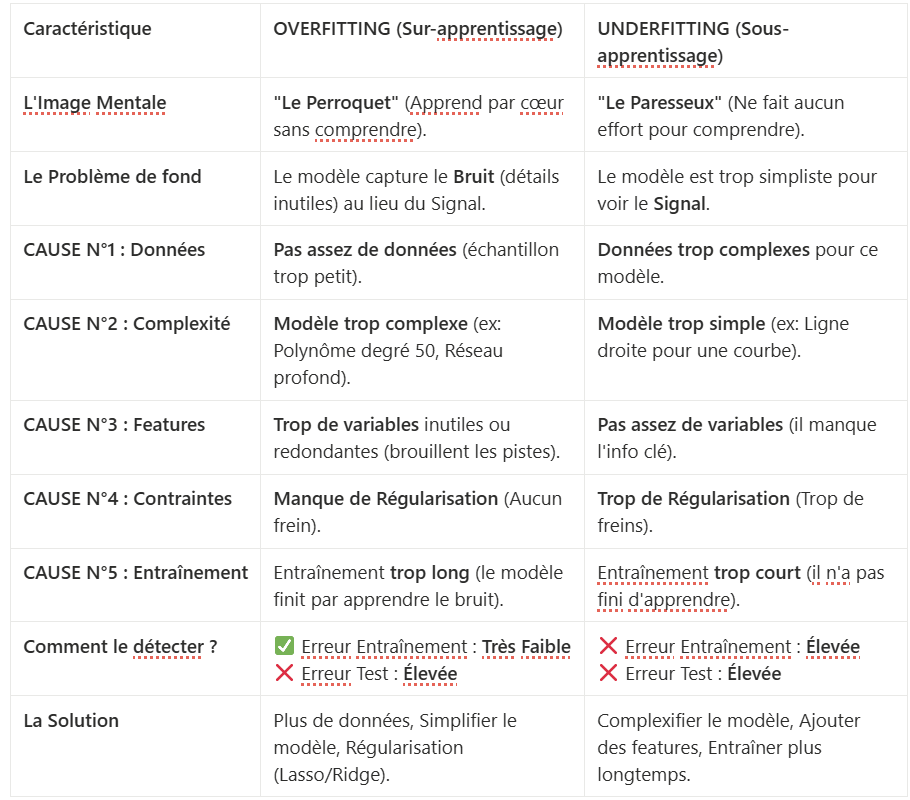

### Comment corriger les problèmes ? (Solutions Pratiques)

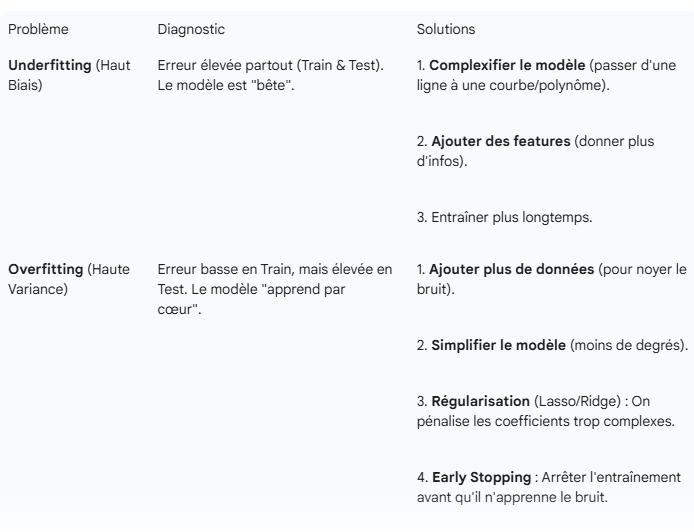

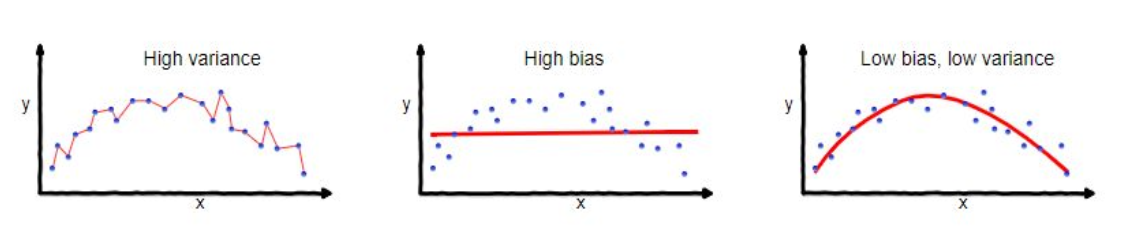